In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch

from tqdm.notebook import tqdm
from scipy.stats import wilcoxon, mannwhitneyu, ttest_ind

from scFM_density_estimation.models import *
from scFM_density_estimation.datamodules import *
from scFM_density_estimation.utils import *

In [22]:
def prepare_batch(X, C, num_classes, num_conditions, batch_size, device):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    
    cond = []
    for i in range(num_conditions):
        cond.append(torch.nn.functional.one_hot(torch.from_numpy(C[:, i][indices]).long(),
                                                num_classes=num_classes[i]).float()
                   )
    cond = torch.cat(cond, dim=1).to(device)
    
    return x1, cond

def prepare_mixed_condition_batch(X, C, num_classes, num_conditions, batch_size, device, probability, index):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    
    cond = []
    for i in range(num_conditions):
        cond.append(torch.nn.functional.one_hot(torch.from_numpy(C[:, i][indices]).long(),
                                                num_classes=num_classes[i]).float()
                   )
    cond = torch.cat(cond, dim=1).to(device)

    row_mask = np.random.random(cond.shape[0]) < probability
    col_mask = [True if sum(num_classes[:index]) <= i < sum(num_classes[:index+1])
                else False for i in range(sum(num_classes))]
    cond[np.ix_(row_mask, col_mask)] = 0
    
    return x1, cond

def weighted_wasserstein(X, C, model):
    generated_samples = model.run_simulation(X, C, n_steps=100)
        
    ws_dist = 0
    combined_conditions = C.cpu().numpy()
    unique_conditions = np.unique(combined_conditions, axis=0)
    
    for condition in unique_conditions:
        mask = np.all(combined_conditions == condition, axis=1)
        ws_dist += wasserstein(X[mask], generated_samples[mask]) * np.sum(mask)

    return ws_dist / C.shape[0]

def softmax(x):
    e_x = np.exp(x)
    return e_x / e_x.sum(axis=-1, keepdims=True)

def stable_softmax(x):
    x = np.asarray(x)
    x_max = np.max(x, axis=-1, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

In [45]:
adata = sc.read_h5ad("/lustre/groups/ml01/projects/inverse_perturbation_models/datasets/pbmc/adata_for_cellflow_datasets_with_embeddings_and_200PCs.h5ad")
label = "cytokine"
X = adata.obsm["X_pca"]
C = np.stack([adata.obs["cytokine"].cat.codes.values.copy()], axis=1)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 4096
cond_dims = [91]
num_cond = len(cond_dims)
dim = 200
use_ot_sampler = False
model = ConditionalFlowMatching.load_from_checkpoint("../outputs/scfm_run_['cytokine']_[1024, 1024, 1024, 1024]_0_0_best-checkpoint.ckpt").to(device)

**General tests**

In [12]:
x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
weighted_wasserstein(x1, cond, model)

8.568575624292997

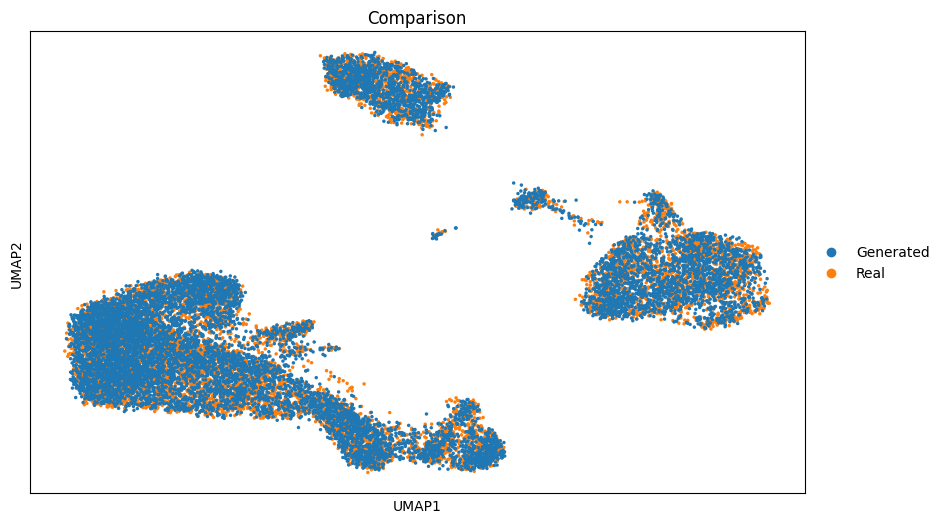

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


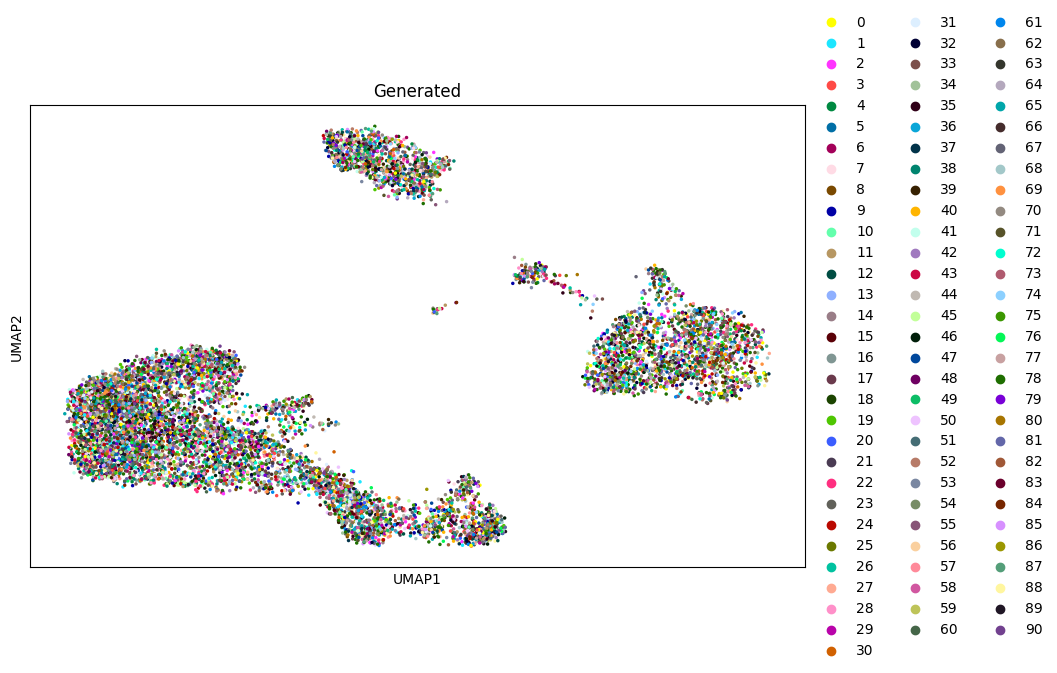

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


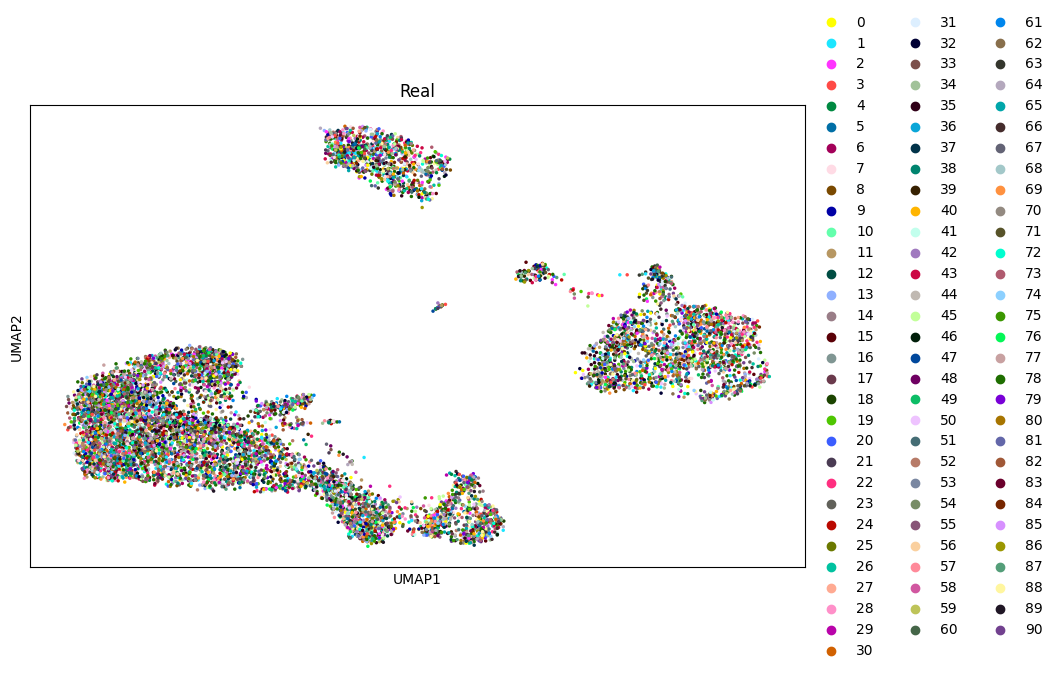

In [13]:
x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
generated_samples = model.run_simulation(x1, cond, n_steps=100)

plot_simulation_scanpy(generated_samples=generated_samples.cpu().numpy(),
                       data_samples=x1.cpu().numpy(), condition=cond.cpu().numpy(),
                       cond_dims=cond_dims, num_cond=num_cond, subsample_size=None,
                       size=25, figsize=(10, 6))

**Single condition classification test**

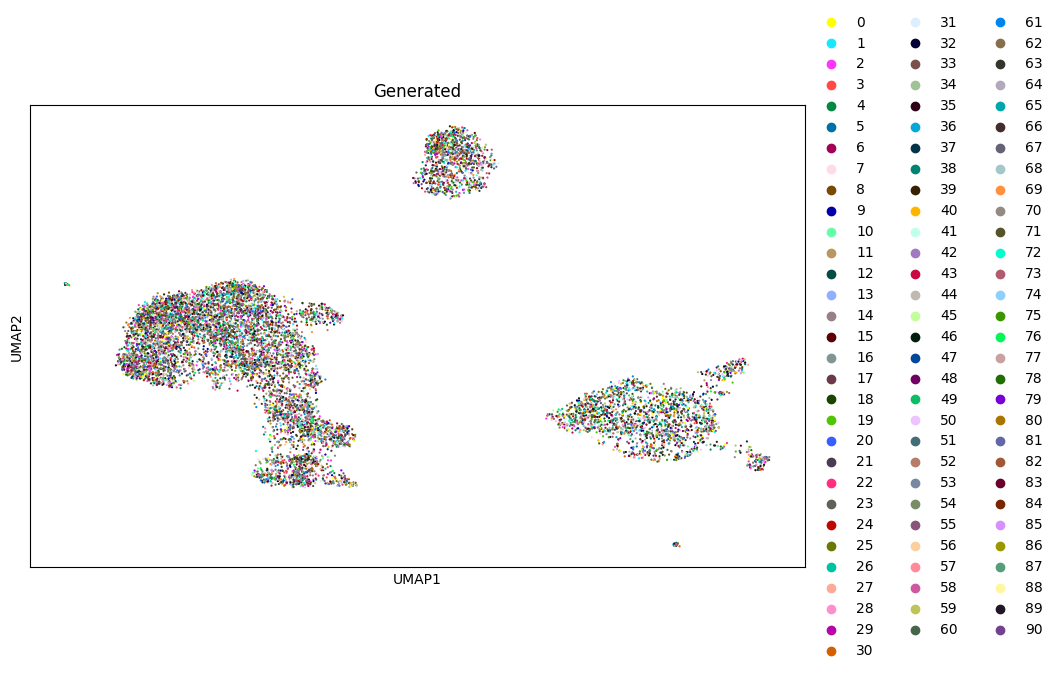

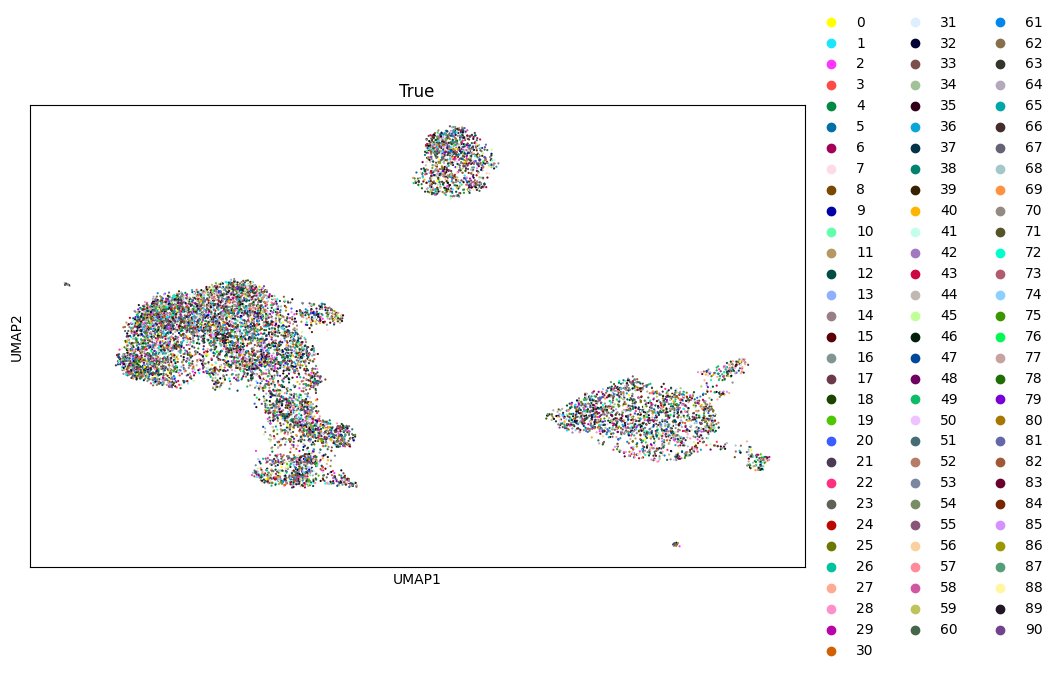

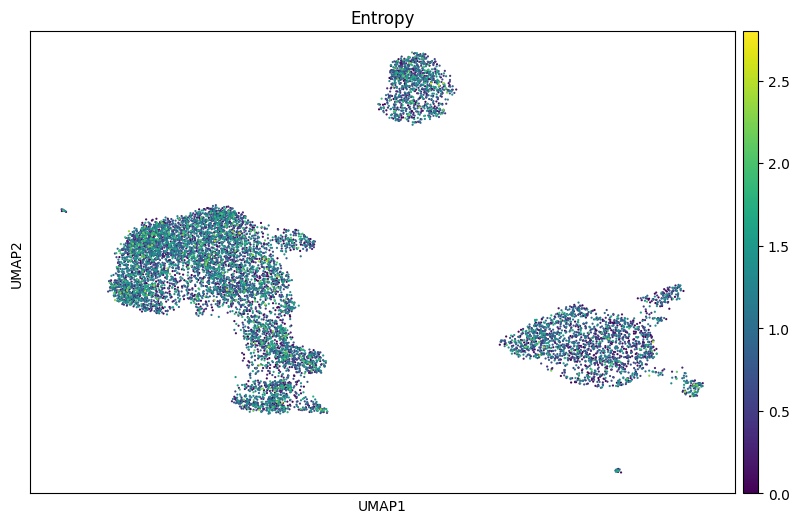

In [23]:
log_density = []
x1, cond_orig = prepare_batch(X, C, cond_dims, num_cond, 10000, device)

unique_conditions = np.unique(cond_orig.cpu().numpy(), axis=0)
for condition in tqdm(unique_conditions):
    cond = torch.from_numpy(condition).expand(cond_orig.shape).float().to(device)
    log_density.append(model.estimate_log_density(x1, cond, n_steps=100).reshape(-1, 1))
log_density = np.concatenate(log_density, axis=1)
color = np.argmax(log_density, axis=1)
    
probs = stable_softmax(log_density)
entropy = -np.sum(probs * np.log(probs + 1e-6), axis=1)

color_orig = np.zeros_like(color)
for i in range(unique_conditions.shape[0]):
    mask = np.all(cond_orig.cpu().numpy() == unique_conditions[i], axis=1)
    color_orig[mask] = i

plot_classification_scanpy(data_samples=x1.cpu().numpy(), color=color,
                           color_orig=color_orig, entropy=entropy,
                           subsample_size=None, size=10, figsize=(10, 6))

In [28]:
np.sum(color == color_orig) / color.shape[0]

0.0221

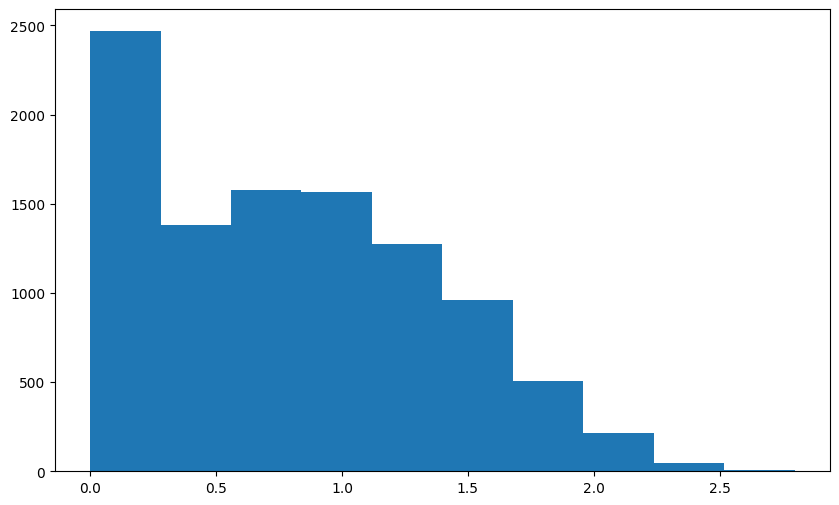

In [36]:
plt.hist(entropy)
plt.show()

In [34]:
np.sum(color[entropy<=0.01] == color_orig[entropy<=0.01]) / color[entropy<=0.01].shape[0]

0.07692307692307693

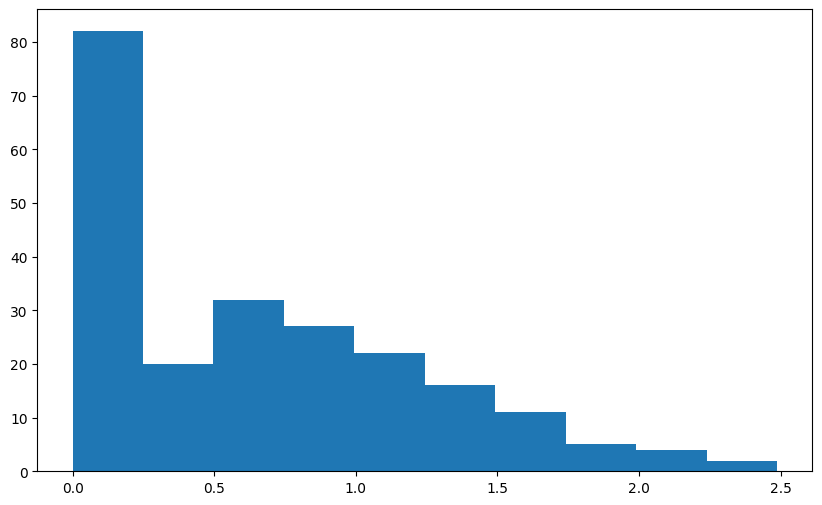

In [38]:
plt.hist(entropy[color == color_orig])
plt.show()

In [40]:
log_density[0]

array([310.10245, 313.5327 , 317.51834, 303.16376, 303.40546, 296.03506,
       310.74878, 310.70343, 297.50983, 300.49203, 309.6347 , 299.1421 ,
       310.9753 , 314.95422, 303.04565, 296.404  , 291.36276, 299.56805,
       304.1892 , 313.72925, 298.89923, 297.8651 , 312.69342, 305.76443,
       306.20642, 298.12555, 313.61548, 294.9239 , 316.41794, 306.1177 ,
       296.87552, 307.9258 , 306.1837 , 296.18347, 319.2656 , 305.10168,
       310.61554, 323.23053, 319.9033 , 287.6494 , 299.24545, 318.85608,
       299.45706, 303.76318, 301.90234, 300.12125, 301.21045, 306.9953 ,
       300.54953, 302.4469 , 313.9179 , 301.67578, 294.78738, 303.49048,
       292.28442, 301.02975, 291.09357, 295.4535 , 303.81842, 298.77542,
       297.18787, 299.8899 , 292.50992, 305.47586, 299.8349 , 297.48148,
       295.72485, 312.21106, 290.9311 , 302.1955 , 314.33728, 299.62912,
       306.65488, 312.09332, 307.58768, 302.3816 , 299.32806, 305.59018,
       314.9796 , 311.7774 , 295.43634, 298.77393, 

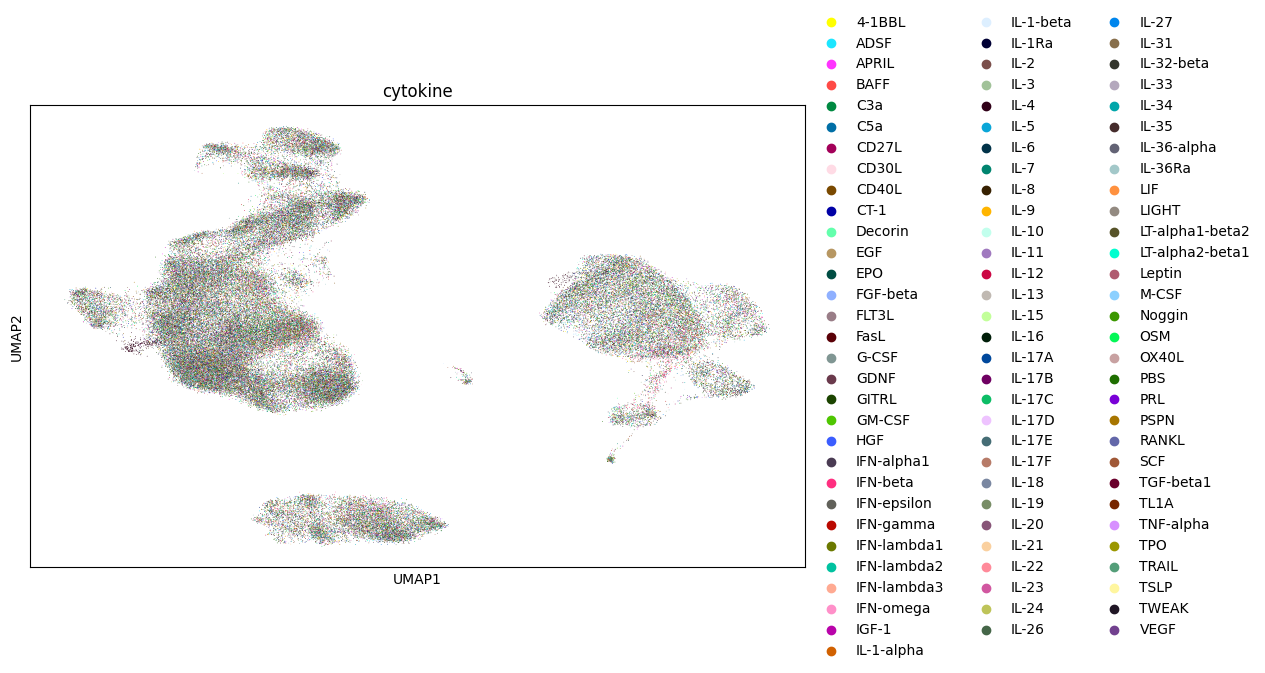

In [46]:
adata_small = sc.pp.subsample(adata, 0.01, copy=True)
sc.pp.neighbors(adata_small)
sc.tl.umap(adata_small)
sc.pl.umap(adata_small, color="cytokine")

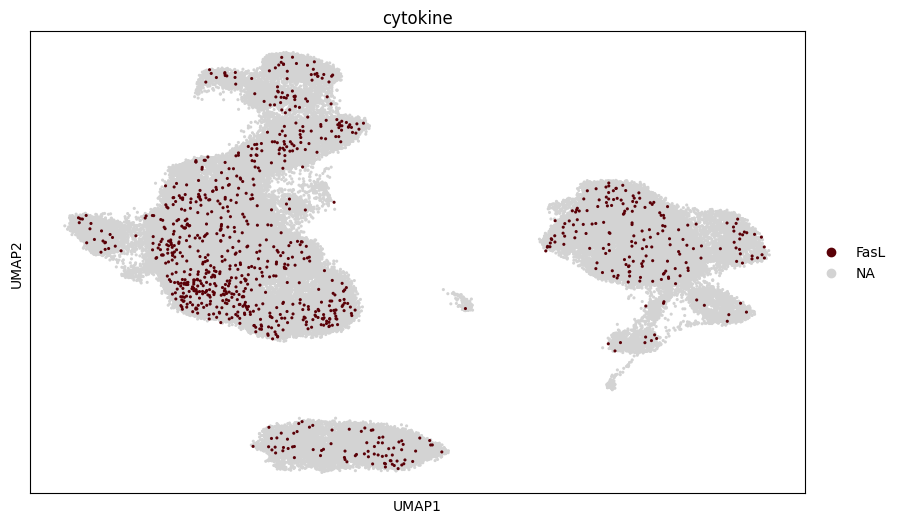

In [48]:
sc.pl.umap(adata_small, color="cytokine", groups="FasL", s=20)